This code aims to fit KPFM images line by line into a time series. 
Images must be imported as .npy for correct fitting. 

In [35]:
#Imports
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import scipy.stats as stats 
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import tkinter as tk
from tkinter import filedialog
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

In [36]:
#Input directory and file saving function 
root = tk.Tk()
root.withdraw()
print("If pop up box not seen minimise spyder and select folder wanted for analysis")
#folder_path = filedialog.askdirectory(title='Select input folder')
#save_path = filedialog.askdirectory(title='Select Folder to Save Plot')


def save_plot_with_folder_dialog(fig, default_filename='plot.jpeg'):
    root = tk.Tk()
    root.withdraw()  # Hide the root window

    folder_path = filedialog.askdirectory(title='Select Folder to Save Plot')
    if not folder_path:
        print("Save cancelled.")
        return

    full_path = os.path.join(folder_path, default_filename)
    fig.savefig(full_path)
    print(f"Plot saved to: {full_path}")
    
def save_plot_to_folder(fig, folder_path, filename='plot.jpeg'):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)  # Create the folder if it doesn't exist
    
    full_path = os.path.join(folder_path, filename)
    fig.tight_layout()
    fig.savefig(full_path, dpi=600, bbox_inches='tight')
    print(f"Plot saved to: {full_path}")

If pop up box not seen minimise spyder and select folder wanted for analysis


In [37]:
#Colourmap formatting
# Change c1 and c2 based on the min and max colours to be chosen 

def hex_to_RGB(hex_str):
    
    """ #FFFFFF -> [255,255,255]"""
    
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):

    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


colors=[]
c1='#1A85FF'#deep blue
c2='#D41159' # deep pink


GB_U_color = "#5CBBFF"
GI_U_color = "#003357"
GB_P_color = "#D69AAB"
GI_P_color = "#8D1730"

In [38]:
#Single Gaussian Fitting function: 
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

In [39]:
# Gaussian fitting function using data from a dataset (i.e. from each individual file) 
def fit_gaussian_from_dataset(x_data, y_data):
    """
    Fit a Gaussian curve to the provided dataset (x_data, y_data).
    Args:
    - x_data: Array-like, x values of the data
    - y_data: Array-like, y values of the data
    
    Returns:
    - A_fit: Amplitude of the fitted Gaussian
    - mu_fit: Mean (center) of the fitted Gaussian
    - sigma_fit: Standard deviation (width) of the fitted Gaussian
    - popt: Optimal parameters from curve fitting
    - pcov: Covariance matrix
    """
    # Initial guess for the parameters [A, mu, sigma]
    initial_guess = [max(y_data), np.mean(x_data), np.std(x_data)]

    try:
        # Fit the Gaussian curve to the data
        popt, pcov = curve_fit(gaussian, x_data, y_data, p0=initial_guess, maxfev=100000000)
        
        # Extract fitted parameters
        A_fit, mu_fit, sigma_fit = popt
        
        # Return the fitted parameters and covariance matrix
        return A_fit, mu_fit, sigma_fit, popt, pcov

    except Exception as e:
        print(f"Error fitting Gaussian: {e}")
        return None, None, None, None, None

In [40]:
# Fitting all images within a folder: 
def fit_gaussian_for_npy(file_directory, image_time):
    
    # Data containers 
    time_scatter = []
    gaussian_peaks = []
    gaussian_min = []
    gaussian_max = []
    fwhm_array =  []
    
    # Sorting all files: 
    search_path = os.path.join(file_directory, '*.npy')
    file_list=glob.glob(search_path)
    file_list.sort()
    if not file_list:
            print("No .npy files found.")
            return

    # Setting global plotting parameters: 
    dpi_setting = 600
    figsize_x, figsize_y = (2227/dpi_setting), (1498/dpi_setting) # ~3.7 x 2.5 inches
    base_font_size = 12
    plt.rcParams.update({'font.size': base_font_size})
    # Plotting fit of last line ONLY
    fig, ax = plt.subplots(figsize=(figsize_x, figsize_y))
    #Processing files in order: 

    total_line_counter = 0
    

    for idx, file_path in enumerate(tqdm(file_list, desc="Processing images")):
            # Expected shape (32,64)
            #Flipping images for correct time order: 
            raw_image=np.load(file_path)
            #Reversing image direction to match scan direction. 
            data=np.flipud(raw_image)
            #data=raw_image

            for r in range(data.shape[0]): 
                line_data=data[r,:]
                counts, bin_edges = np.histogram(line_data, bins='auto', density=True)
                bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
                total_line_counter=total_line_counter+1
                time_scatter.append(image_time*total_line_counter-image_time)
                try:
                    # Initial guess: [Amplitude, Mean, Sigma]
                    p0 = [np.max(counts), np.mean(line_data), np.std(line_data)]
                    popt, _ = curve_fit(gaussian, bin_centres, counts, p0=p0, maxfev=1000000)
                    
                    # Extract results
                    amp, cen, sigma = popt
                    fwhm = 2.355 * abs(sigma)

                    # Appending to lists: 
                    gaussian_peaks.append(cen)
                    gaussian_min.append(cen - fwhm/2)
                    gaussian_max.append(cen + fwhm/2)
                    # Plotting only the last line as a visual check
                    if idx == len(file_list)-1 and r == data.shape[0]-1:
                        ax.scatter(bin_centres, counts, s=10, alpha=0.5, label="Raw Data (Last Line)")
                        x_fine = np.linspace(bin_centres.min(), bin_centres.max(), 100)
                        ax.plot(x_fine, gaussian(x_fine, *popt), 'r-', linewidth=2, label="Gaussian Fit")
                        #for i in len(gaussian_peaks):
                        #     time_scatter.append()
                except Exception as e:
                    # If a specific line fails to fit, we skip it to keep the code running
                    continue

    #Final Plotting: 
    ax.set_xlabel("SPV (V)")
    ax.set_ylabel("Distribution (V$^{-1}$)")
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))    
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))    
    ax.tick_params(direction='in', length=6, top=True, right=True)
    plt.tight_layout()
    plt.show()
    gaussian_peaks_mV=[round(x*1000,4) if not np.isnan(x) else np.nan for x in gaussian_peaks]
    gaussian_min_mV=[round(x*1000,4) if not np.isnan(x) else np.nan for x in gaussian_min]
    gaussian_max_mV=[round(x*1000,4) if not np.isnan(x) else np.nan for x in gaussian_max]
    print(f"Processed {len(gaussian_peaks)} lines successfully.")
    return time_scatter, gaussian_peaks_mV, gaussian_min_mV,gaussian_max_mV
                            

In [41]:
# Exponential fitting: 
# Adjusted exponential fit to check: 

def adjusted_exponential(t, A, tau, const):
    return A*(1-np.exp(-(t/tau)))+const


In [42]:
# Adjusted exponential fitting function: 
def exponential_plotting(gaussian_peaks, x_data):#, sampletype, save_path):
    try: 
        # Fit the data using curve_fit
        #defining initial guesses: 
        A_initial = np.max(gaussian_peaks)#If data is positive then this should be max, if negative then it is min
        tau_initial= np.median(x_data) #Can also try max/2 or mean to see if this works
        const_initial=np.min(gaussian_peaks)
        print(f"Constant initial = {const_initial:.2f}")
        initial_guess = [A_initial,tau_initial, const_initial]  # Initial guess for A, tau, const
        params, covariance = curve_fit(adjusted_exponential, x_data, gaussian_peaks, p0=initial_guess, maxfev=1000000)
        #k_initial = 1/tau_initial
        # Extract the parameters (A, tau, beta)
        A, tau, const = params
        print("Fitted Parameters:")
        print(f"A = {A:.2f}")
        print(f"tau = {tau:.2f}")
        print(f"constant={const:.2f}")


        # Generate 1000 new x values between the minimum and maximum of original x_data
        x_fit= np.linspace(np.min(x_data), np.max(x_data), 1000000)
        #y_fit= adjusted_exponential(x_fit, *params)
        y_fit = np.array([adjusted_exponential(np.array([x]), *params)[0] for x in tqdm(x_fit, desc="Fitting")])
        
        #start_SPV_sat = np.where(x_fit==int(tau))
        for x in x_fit: 
            if x_fit[x]== np.int(tau): 
                start_SPV_ss = x
            else: 
                print ("Error finding index")
        end_SPV_ss = len(x_fit)
        SPV_ss = np.mean(y_fit[start_SPV_ss:end_SPV_ss])
        SPV_ss_err = np.std(y_fit[start_SPV_ss:end_SPV_ss])/np.sqrt(len(x_fit))
        print(f"SPV_sat = {SPV_ss:.4f}mV, std = {SPV_ss_err:.4f}mV")

        #print(np.max(x_data))
    #    y_initial = y_data[0]
        # Calculate 37% of the initial value (A)
    #   y_37_percent = 1.37 * y_initial
        
        # Find the x-value where y reaches 37% of its initial value
        # We use np.abs to find the closest value in y_data to the target y_37_percent
    #   closest_idx = np.argmin(np.abs(y_fit - y_37_percent))
    #  x_at_37_percent = x_fit[closest_idx]

    # print(f"37% of initial CPD is: {y_37_percent:.2f}")
    # print(f"Time (x-value) when y reaches 37% of its initial value: {x_at_37_percent:.2f}")
        
        # Plotting data:
        dpi_setting = 600
        figsize_x, figsize_y = (2227/dpi_setting), (1498/dpi_setting)
        tick_length = 6
        legend_font = 12
        base_font_size = 12
        scatter_size = 6
        line_width = 1.5
        plt.figure(figsize=(figsize_x, figsize_y))
        plt.rcParams.update({'font.size': base_font_size})
        ax = plt.gca()
        ax.tick_params(direction='in', length=tick_length)
        ax.tick_params(axis='both')
        #ax.margins (0.3,0.3)
        plt.xlabel("Time (s)")
        plt.ylabel("SPV (mV)")
        # Limit number of ticks

        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis
        plt.scatter(x_data, gaussian_peaks, label='Raw Data', color=GI_U_color, s=scatter_size)
        plt.plot(x_fit, y_fit, label='Fitted Data', color='#6F6F6F', linewidth=line_width)
        plt.axhline(y=tau, color='black', linestyle='--', label = 'Tau')
        plt.autoscale(enable=True, axis='y', tight=False)

        #uncomment for saving figures
    #    fig=plt.gcf()
    #    save_plot_to_folder(fig, save_path,filename=f'FittedScatter_{sampletype}.jpeg')
        #Automatically adjust the y-axis
        
    except Exception as e: 
        print("Fitting has failed. See errors or just come back later.")
        print(e.args)

    plt.show()
    return x_fit, y_fit, SPV_ss, SPV_ss_err

In [43]:
# Set global parameters where needed. Rows not needed if importing images. 
image_time= 1.33 #s
#save_path = filedialog.askdirectory(title='Select input folder')

Processing images: 100%|██████████| 30/30 [00:01<00:00, 26.01it/s]


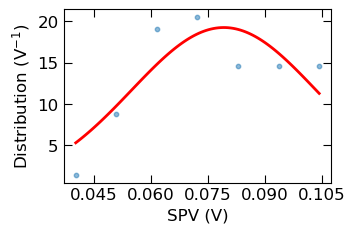

Processed 960 lines successfully.


In [57]:
Unpass_On = filedialog.askdirectory(title='Select input folder')
#Fitting line by line to get temporal SPV
UnpassOn_Time, UnpassOn_peaks, UnpassOn_min,UnpassOn_max= fit_gaussian_for_npy(Unpass_On, image_time)
#Plotting for shaded plots: 

#Fitting temporal SPV for tau
#UnpassOn_x_fit, UnpassOn_y_fit, UnpassOn_SPV_ss, UnpassOn_SPV_ss_std =  exponential_plotting( UnpassOn_peaks, UnpassOn_Time)#, sampletype='Unpassivated_Illuminated', save_path)



Processing images: 100%|██████████| 31/31 [00:00<00:00, 36.84it/s]


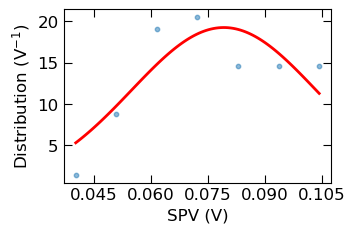

Processed 992 lines successfully.


In [60]:
UnpassOn_Time, UnpassOn_peaks, UnpassOn_min,UnpassOn_max= fit_gaussian_for_npy(Unpass_On, image_time)



In [46]:
print(UnpassOn_peaks)
print(UnpassOn_Time)

[440.0704, 410.8824, 413.6667, 393.0236, 390.0778, 386.5415, 371.4134, 375.9337, 360.0609, 361.7071, 360.3523, 360.7555, 356.5605, 355.8844, 354.4453, 354.2743, 358.7057, 353.5264, 345.0899, 347.6195, 343.6237, 349.4737, 346.9989, 345.3073, 346.9088, 344.1934, 342.473, 336.7728, 344.121, 338.7296, 341.4846, 336.3273, 155.4924, 144.8646, 150.5735, 133.1706, 131.9991, 139.9817, 131.5408, 140.0462, 133.2532, 131.4767, 127.1349, 134.9055, 126.0313, 129.0866, 129.1066, 130.6516, 137.5192, 127.5716, 126.4086, 123.8775, 124.93, 122.895, 121.6497, 125.4593, 122.2102, 118.248, 117.9201, 113.3215, 118.3538, 117.0005, 114.4868, 108.6189, 169.8256, 141.6783, 140.1876, 123.7746, 133.0066, 127.6466, 119.5243, 121.7896, 119.1589, 117.0602, 114.4228, 120.0725, 110.0977, 113.7035, 115.8648, 119.7631, 125.8765, 117.6541, 115.7426, 119.2114, 111.0795, 111.718, 108.6829, 115.2605, 108.896, 109.5487, 105.8671, 105.2259, 105.9675, 101.5996, 105.0351, 101.9861, 145.7269, 135.7494, 144.8316, 128.7835, 133.081

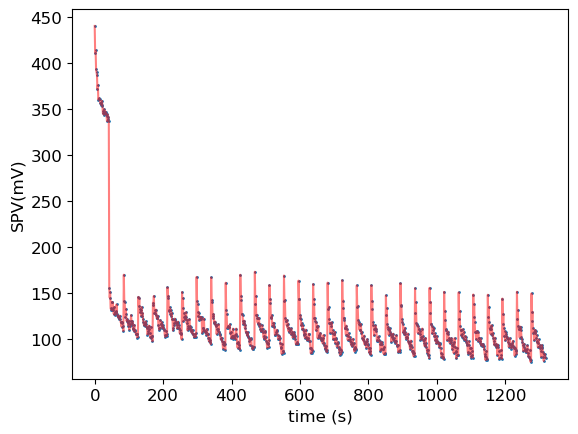

992


In [62]:
plt.scatter(UnpassOn_Time, UnpassOn_peaks, s=1)
plt.plot(UnpassOn_Time, UnpassOn_peaks, color='red', alpha = 0.5)
#plt.vlines(x=UnpassOn_Time[32], ymin=0, ymax=450, linestyles='-.')
plt.xlabel('time (s)')
plt.xlabel('time (s)')
plt.ylabel('SPV(mV)')
plt.show()
print(len(UnpassOn_peaks))


In [48]:
np.argmax(UnpassOn_peaks)

0

In [49]:
#Unpass_Off = filedialog.askdirectory(title='Select input folder')

In [50]:
#Pass_On = filedialog.askdirectory(title='Select input folder')

In [51]:
#Pass_Off = filedialog.askdirectory(title='Select input folder')